In [62]:
!python -m pip install -U pip
!python -m pip install -U pandas scikit-learn

In [63]:
#read csv file
import pandas as pd
df = pd.read_csv(r"C:\Users\UserName\Desktop\가천대학교\26-1학기\데이터과학\Week6_phw1_bmi_data.csv")

# Peak into the dataset(data exploration)

## Print dataset statictical data, feature names and data types

In [64]:
print(df)

        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21        65.783310       112.992500  2.0
1    Female   35              NaN       136.487300  3.0
2    Female   27        69.398740       153.026900  3.0
3      Male   24        68.216600       142.335400  3.0
4    Female   18        67.787810       144.297100  3.0
5    Female   22        68.697840       123.302400  2.0
6      Male   35        69.802040       141.494700  NaN
7      Male   19        70.014720       136.462300  3.0
8    Female   28        67.902650       112.372300  2.0
9      Male   25              NaN       120.667200  3.0
10     Male   34         0.000000       127.451600  NaN
11   Female   28        67.623330       114.143000  2.0
12     Male   21        68.302480       125.610700  3.0
13     Male   25        67.116560       122.461800  3.0
14   Female   27        68.279670       116.086600  2.0
15     Male   23        71.091600       139.997500  3.0
16     Male   20        66.461000       129.5023

In [65]:
#print feature names
print(df.columns)

Index(['Sex', 'Age', 'Height (Inches)', 'Weight (Pounds)', 'BMI'], dtype='str')


In [66]:
# print dataset statistical data
print(df.describe())

              Age  Height (Inches)  Weight (Pounds)         BMI
count  150.000000       146.000000       150.000000  145.000000
mean    26.413333        80.133994       129.703405    2.751724
std      5.206071        96.579662        88.179891    0.449244
min     18.000000      -130.926162      -161.994913    1.000000
25%     22.000000        66.599598       120.391125    3.000000
50%     26.500000        68.219095       128.538050    3.000000
75%     31.000000        69.432848       136.170900    3.000000
max     35.000000       665.465059      1110.621115    3.000000


In [67]:
# print columns, non-null counts, and data types
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sex              150 non-null    str    
 1   Age              150 non-null    int64  
 2   Height (Inches)  146 non-null    float64
 3   Weight (Pounds)  150 non-null    float64
 4   BMI              145 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 6.7 KB
None


check missing values

In [68]:
print(df['BMI'].value_counts())

BMI
3.0    110
2.0     34
1.0      1
Name: count, dtype: int64


In [69]:
print(df['BMI'].unique())
# 5 nan values in bmi column

[ 2.  3. nan  1.]


In [70]:
print(df['Height (Inches)'].isnull().sum())
# 4 nan values in height column

4


## Plot height and weight histograms (bins = 10) for each BMI value

In [71]:
# Plot height & weight histograms (bins=10) for each BMI value
!python -m pip install -U matplotlib
import matplotlib.pyplot as plt


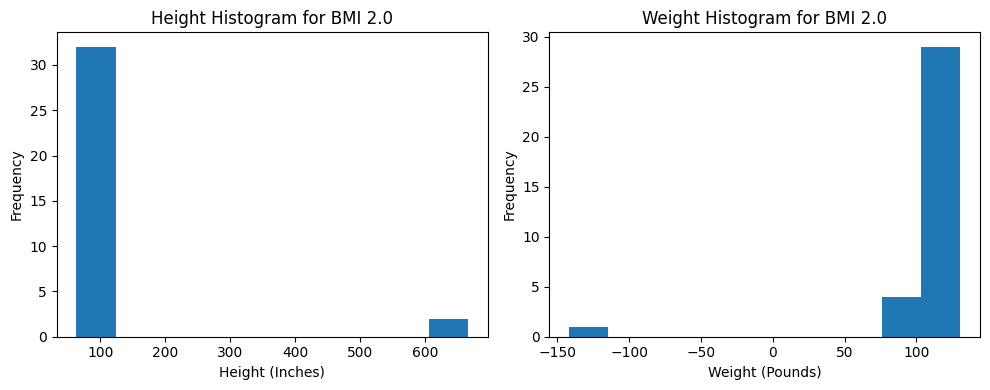

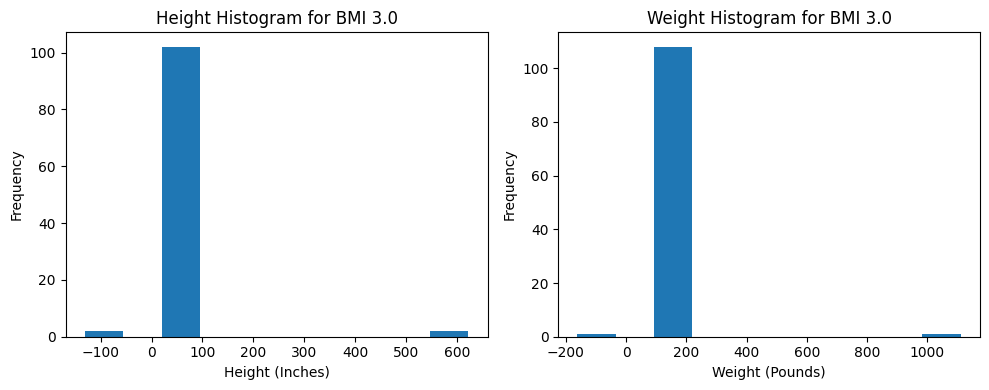

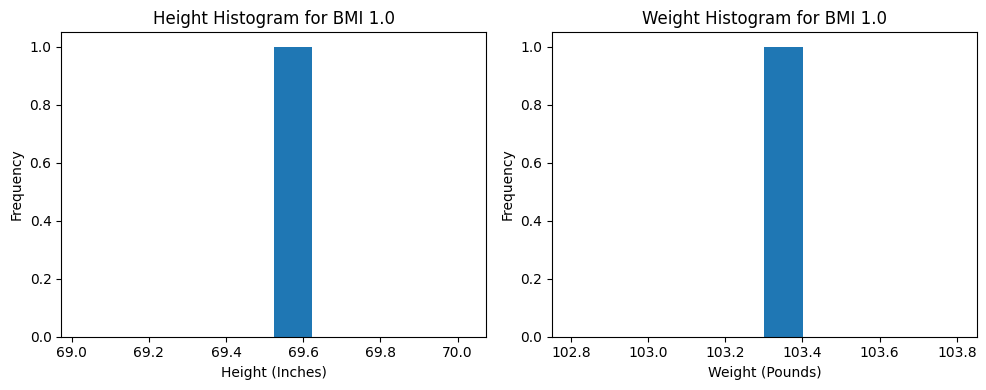

In [72]:
# Using matplotlib.pyplot.subplots
unique_bmis = df['BMI'].unique()
for bmi in unique_bmis:
    if pd.isnull(bmi): # Skip NaN BMI values
        continue
    subset = df[df['BMI'] == bmi]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(subset['Height (Inches)'], bins=10)
    plt.title(f'Height Histogram for BMI {bmi}')
    plt.xlabel('Height (Inches)')
    plt.ylabel('Frequency')
    plt.subplot(1, 2, 2)
    plt.hist(subset['Weight (Pounds)'], bins=10)
    plt.title(f'Weight Histogram for BMI {bmi}')
    plt.xlabel('Weight (Pounds)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [73]:
# Using seaborn.FacetGrid
!python -m pip install -U seaborn
import seaborn as sns

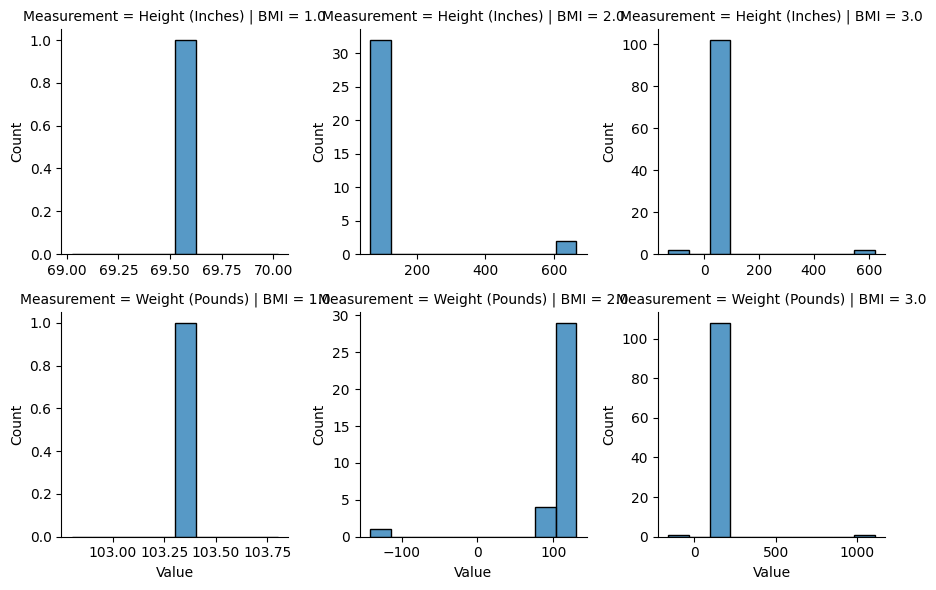

In [74]:
# using seaborn.FacetGrid
import seaborn as sns

# Melt the dataframe for FacetGrid
melted = df.melt(id_vars='BMI', value_vars=['Height (Inches)', 'Weight (Pounds)'], var_name='Measurement', value_name='Value')

# Create FacetGrid
g = sns.FacetGrid(melted, col='BMI', row='Measurement', sharex=False, sharey=False)
g.map(sns.histplot, 'Value', bins=10)
g.add_legend()
plt.show()

## Plot scaling results for height and weight

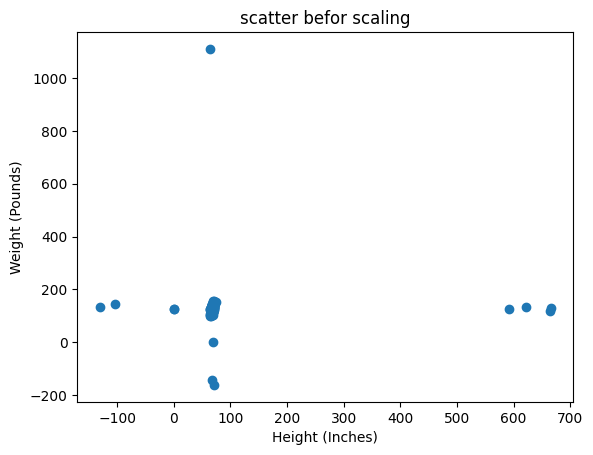

In [75]:
# Before Scaling
plt.scatter(df['Height (Inches)'], df['Weight (Pounds)'])
plt.xlabel('Height (Inches)') #x name
plt.ylabel('Weight (Pounds)') #y name
plt.title('scatter befor scaling')
plt.show()

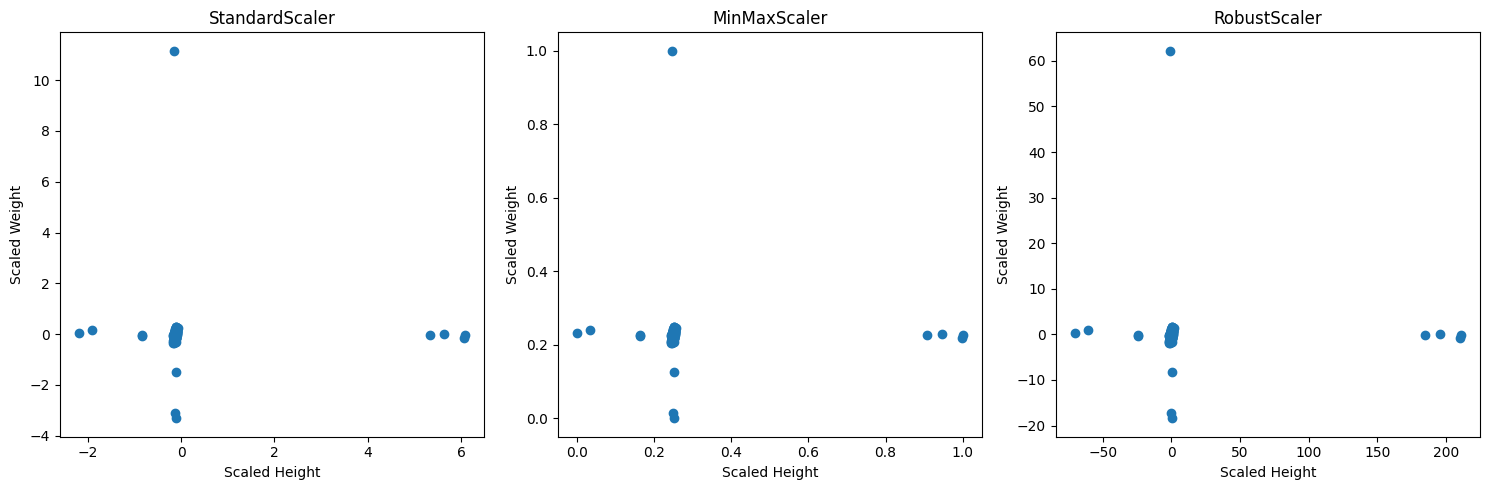

In [76]:
# After scaling(StandardScaler, MinMaxScaler, RobustScaler)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import matplotlib.pyplot as plt

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, scaler) in zip(axes, scalers.items()):
    scaled = scaler.fit_transform(df[['Height (Inches)', 'Weight (Pounds)']])
    ax.scatter(scaled[:, 0], scaled[:, 1])
    ax.set_title(f'{name}')
    ax.set_xlabel('Scaled Height')
    ax.set_ylabel('Scaled Weight')

plt.tight_layout() # 서브 플롯들이 서로 겹치지 않게 자동으로 레이아웃을 조정
plt.show()

## Missing value manipulation

missing value

(2, 2) height 값 존재 X,

(10, 2) height 값 존재 X,

(34, 2) height 값 존재 X,

(91, 2) height 값 존재 X,

(49, 4) bmi 값 존재 X,

(7, 4) bmi 값 존재 X,

(11, 4) bmi 값 존재 X,

(55, 4) bmi 값 존재 X,

(70, 4) bmi 값 존재 X

wrong value

(11, 2) height 값 0,

(18, 2) height 값 음수(-104.4206),

(42, 2) height 값 592.6244,

(48, 2) height 값 664.4878,

(70, 2) height 값 0,

(88, 2) height 값 622.0487,

(112, 2) height 값 665.4651,

(117, 2) height 값 -130.9262,

(49, 3) weight 값 0 ,

(105, 3) weight 값 -141.8241,

(130, 3) weight 값 -161.9949,

(148, 4) weight 값 1110.621115

## Cleaning the input dataset

In [77]:
clean_data = df.fillna(0, inplace=True)
# drop row that has 0 or negative value in height and weight column
clean_data = clean_data[clean_data['Height (Inches)'] > 0]
clean_data = clean_data[clean_data['Weight (Pounds)'] > 0]
# drop row that has height value more than 100 and weight value more than 200
clean_data = clean_data[clean_data['Height (Inches)'] < 100]
clean_data = clean_data[clean_data['Weight (Pounds)'] < 200]

In [78]:
print(clean_data)

        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21         65.78331        112.99250  2.0
2    Female   27         69.39874        153.02690  3.0
3      Male   24         68.21660        142.33540  3.0
4    Female   18         67.78781        144.29710  3.0
5    Female   22         68.69784        123.30240  2.0
6      Male   35         69.80204        141.49470  0.0
7      Male   19         70.01472        136.46230  3.0
8    Female   28         67.90265        112.37230  2.0
11   Female   28         67.62333        114.14300  2.0
12     Male   21         68.30248        125.61070  3.0
13     Male   25         67.11656        122.46180  3.0
14   Female   27         68.27967        116.08660  2.0
15     Male   23         71.09160        139.99750  3.0
16     Male   20         66.46100        129.50230  3.0
18     Male   19         71.23033        137.90250  3.0
19   Female   32         67.13118        124.04490  3.0
20     Male   22         67.83379        141.280

In [79]:
print(clean_data.isna().sum())

Sex                0
Age                0
Height (Inches)    0
Weight (Pounds)    0
BMI                0
dtype: int64


In [80]:
pd.set_option('display.max_rows', None)
print(clean_data) # check if all rows with nan, 0, negative, and outlier values are dropped
pd.set_option('display.max_rows', 60)

        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21         65.78331        112.99250  2.0
2    Female   27         69.39874        153.02690  3.0
3      Male   24         68.21660        142.33540  3.0
4    Female   18         67.78781        144.29710  3.0
5    Female   22         68.69784        123.30240  2.0
6      Male   35         69.80204        141.49470  0.0
7      Male   19         70.01472        136.46230  3.0
8    Female   28         67.90265        112.37230  2.0
11   Female   28         67.62333        114.14300  2.0
12     Male   21         68.30248        125.61070  3.0
13     Male   25         67.11656        122.46180  3.0
14   Female   27         68.27967        116.08660  2.0
15     Male   23         71.09160        139.99750  3.0
16     Male   20         66.46100        129.50230  3.0
18     Male   19         71.23033        137.90250  3.0
19   Female   32         67.13118        124.04490  3.0
20     Male   22         67.83379        141.280

In [81]:
# Replace dirty data in height and weight columns with predicted values using linear regression
from sklearn.linear_model import LinearRegression

# Train models on clean data
reg_hw = LinearRegression().fit(clean_data[['Height (Inches)']], clean_data['Weight (Pounds)'])
reg_wh = LinearRegression().fit(clean_data[['Weight (Pounds)']], clean_data['Height (Inches)'])

r_sq_hw = reg_hw.score(clean_data[['Height (Inches)']], clean_data['Weight (Pounds)'])
r_sq_wh = reg_wh.score(clean_data[['Weight (Pounds)']], clean_data['Height (Inches)'])
print('coefficient of determination:', r_sq_hw)
print('coefficient of determination:', r_sq_wh)

# List of indices with dirty data (0-based)
dirty_indices = [1, 9, 33, 90, 48, 10, 17, 41, 47, 69, 87, 111, 116, 48, 104, 129, 147]

# Replace dirty values
for idx in dirty_indices:
    # Check if height is dirty (negative, zero, or unreasonably high)
    if df.loc[idx, 'Height (Inches)'] <= 0 or df.loc[idx, 'Height (Inches)'] > 100:
        # Predict height using weight
        predicted_height = reg_wh.predict([[df.loc[idx, 'Weight (Pounds)']]])[0]
        df.loc[idx, 'Height (Inches)'] = predicted_height
    # Check if weight is dirty (negative or zero)
    if df.loc[idx, 'Weight (Pounds)'] <= 0 or df.loc[idx, 'Weight (Pounds)'] > 200:
        # Predict weight using height
        predicted_weight = reg_hw.predict([[df.loc[idx, 'Height (Inches)']]])[0]
        df.loc[idx, 'Weight (Pounds)'] = predicted_weight

print("Dirty data replaced with predicted values.")

coefficient of determination: 0.31469956845429736
coefficient of determination: 0.3146995684542968
Dirty data replaced with predicted values.


c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\util

## Draw a scatter plot

In [82]:
print(df)

        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21        65.783310       112.992500  2.0
1    Female   35        68.824635       136.487300  3.0
2    Female   27        69.398740       153.026900  3.0
3      Male   24        68.216600       142.335400  3.0
4    Female   18        67.787810       144.297100  3.0
..      ...  ...              ...              ...  ...
145  Female   20        68.262090       116.458800  2.0
146  Female   28        68.568650       133.840200  3.0
147  Female   30        64.496750       114.729083  3.0
148    Male   19        68.710530       130.756800  3.0
149    Male   25        68.891480       137.757100  3.0

[150 rows x 5 columns]


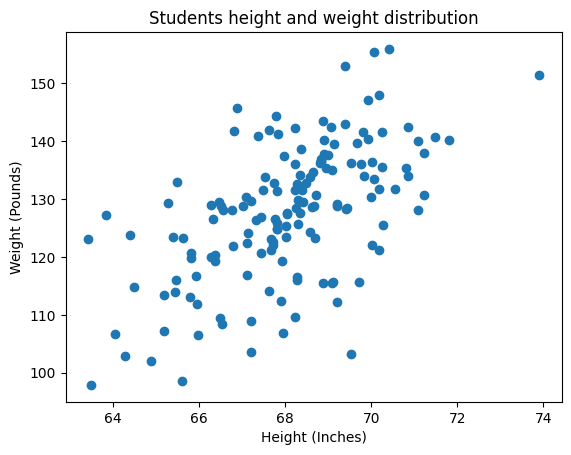

In [83]:
plt.scatter(df['Height (Inches)'], df['Weight (Pounds)'])
plt.xlabel('Height (Inches)') #x name
plt.ylabel('Weight (Pounds)') #y name
plt.title('Students height and weight distribution')
plt.show()

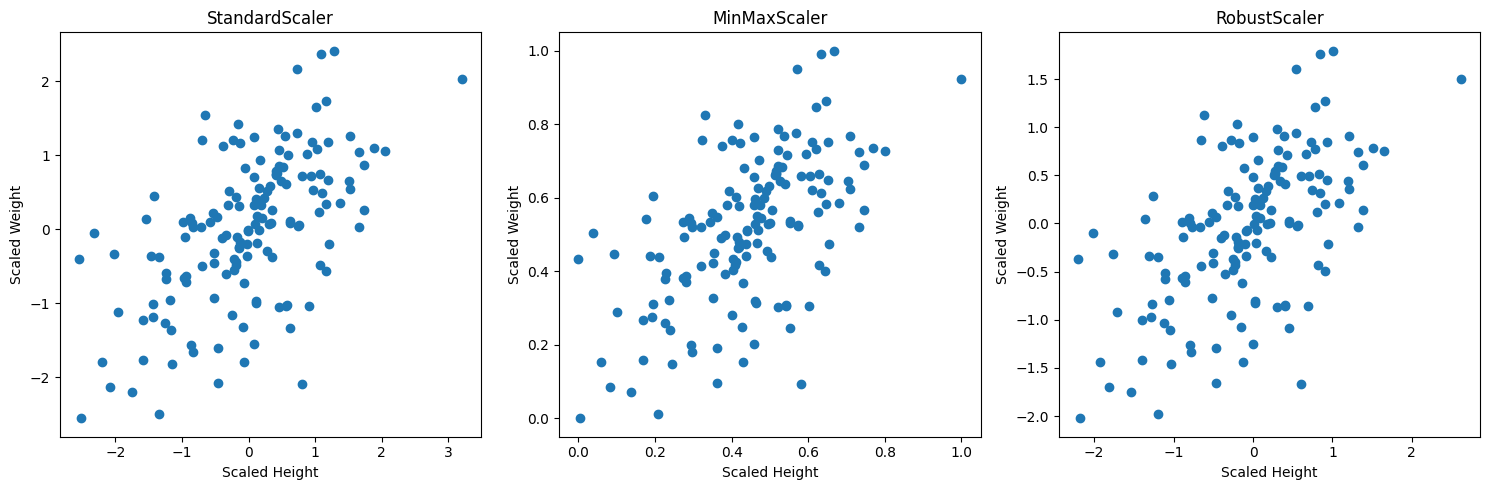

In [84]:
scalers = { #scaling methods
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) #make 3 subplots for each scaling method

for ax, (name, scaler) in zip(axes, scalers.items()): #apply each scaling method to height and weight columns and plot the results
    scaled = scaler.fit_transform(df[['Height (Inches)', 'Weight (Pounds)']])
    ax.scatter(scaled[:, 0], scaled[:, 1])
    ax.set_title(f'{name}')
    ax.set_xlabel('Scaled Height')
    ax.set_ylabel('Scaled Weight')

plt.tight_layout() # 서브 플롯들이 서로 겹치지 않게 자동으로 레이아웃을 조정
plt.show()

## Do the same for the groups diveded by gender

In [85]:
df = pd.read_csv(r"C:\Users\UserName\Desktop\가천대학교\26-1학기\데이터과학\Week6_phw1_bmi_data.csv")

In [86]:
print(df.describe())

              Age  Height (Inches)  Weight (Pounds)         BMI
count  150.000000       146.000000       150.000000  145.000000
mean    26.413333        80.133994       129.703405    2.751724
std      5.206071        96.579662        88.179891    0.449244
min     18.000000      -130.926162      -161.994913    1.000000
25%     22.000000        66.599598       120.391125    3.000000
50%     26.500000        68.219095       128.538050    3.000000
75%     31.000000        69.432848       136.170900    3.000000
max     35.000000       665.465059      1110.621115    3.000000


In [87]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sex              150 non-null    str    
 1   Age              150 non-null    int64  
 2   Height (Inches)  146 non-null    float64
 3   Weight (Pounds)  150 non-null    float64
 4   BMI              145 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 6.7 KB
None


In [88]:
df_female = df[df['Sex']=='Female']
print(df_female)

        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21         65.78331       112.992500  2.0
1    Female   35              NaN       136.487300  3.0
2    Female   27         69.39874       153.026900  3.0
4    Female   18         67.78781       144.297100  3.0
5    Female   22         68.69784       123.302400  2.0
..      ...  ...              ...              ...  ...
142  Female   27         68.00869       125.328700  3.0
143  Female   29         68.33840       127.584600  3.0
145  Female   20         68.26209       116.458800  2.0
146  Female   28         68.56865       133.840200  3.0
147  Female   30         64.49675      1110.621115  3.0

[86 rows x 5 columns]


In [89]:
clean_female_data = df_female.fillna(0, inplace=True)
# drop row that has 0 or negative value in height and weight column
clean_female_data = clean_female_data[clean_female_data['Height (Inches)'] > 0]
clean_female_data = clean_female_data[clean_female_data['Weight (Pounds)'] > 0]
# drop row that has height value more than 100 and weight value more than 200
clean_female_data = clean_female_data[clean_female_data['Height (Inches)'] < 100]
clean_female_data = clean_female_data[clean_female_data['Weight (Pounds)'] < 200]

In [90]:
pd.set_option('display.max_rows', None)
print(clean_female_data)

        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21         65.78331        112.99250  2.0
2    Female   27         69.39874        153.02690  3.0
4    Female   18         67.78781        144.29710  3.0
5    Female   22         68.69784        123.30240  2.0
8    Female   28         67.90265        112.37230  2.0
11   Female   28         67.62333        114.14300  2.0
14   Female   27         68.27967        116.08660  2.0
19   Female   32         67.13118        124.04490  3.0
21   Female   32         68.87881        143.53920  3.0
22   Female   31         63.48115         97.90191  2.0
23   Female   35         68.42187        129.50270  3.0
29   Female   31         65.44098        113.89220  3.0
30   Female   25         69.52330        103.30160  1.0
31   Female   25         65.81320        120.75360  3.0
32   Female   26         67.81630        125.78860  3.0
34   Female   26         71.80484        140.10150  3.0
35   Female   27         69.20613        128.748

In [91]:
print(df_female)

        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21        65.783310       112.992500  2.0
1    Female   35         0.000000       136.487300  3.0
2    Female   27        69.398740       153.026900  3.0
4    Female   18        67.787810       144.297100  3.0
5    Female   22        68.697840       123.302400  2.0
8    Female   28        67.902650       112.372300  2.0
11   Female   28        67.623330       114.143000  2.0
14   Female   27        68.279670       116.086600  2.0
17   Female   31      -104.420555       142.973300  3.0
19   Female   32        67.131180       124.044900  3.0
21   Female   32        68.878810       143.539200  3.0
22   Female   31        63.481150        97.901910  2.0
23   Female   35        68.421870       129.502700  3.0
29   Female   31        65.440980       113.892200  3.0
30   Female   25        69.523300       103.301600  1.0
31   Female   25        65.813200       120.753600  3.0
32   Female   26        67.816300       125.7886

In [92]:
from sklearn.linear_model import LinearRegression

# Train models on clean data
reg_hw = LinearRegression().fit(clean_female_data[['Height (Inches)']], clean_female_data['Weight (Pounds)'])
reg_wh = LinearRegression().fit(clean_female_data[['Weight (Pounds)']], clean_female_data['Height (Inches)'])

# List of indices with dirty data
dirty_indices = [1, 17, 41, 69, 87, 90, 104, 129, 147]

r_sq_hw = reg_hw.score(clean_female_data[['Height (Inches)']], clean_female_data['Weight (Pounds)'])
r_sq_wh = reg_wh.score(clean_female_data[['Weight (Pounds)']], clean_female_data['Height (Inches)'])
print('coefficient of determination:', r_sq_hw)
print('coefficient of determination:', r_sq_wh)

# Replace dirty values
for idx in dirty_indices:
    # Check if height is dirty (negative, zero, or unreasonably high)
    if df_female.loc[idx, 'Height (Inches)'] <= 0 or df_female.loc[idx, 'Height (Inches)'] > 100:
        # Predict height using weight
        predicted_height = reg_wh.predict([[df_female.loc[idx, 'Weight (Pounds)']]])[0]
        df_female.loc[idx, 'Height (Inches)'] = predicted_height
    # Check if weight is dirty (negative or zero)
    if df_female.loc[idx, 'Weight (Pounds)'] <= 0 or df_female.loc[idx, 'Weight (Pounds)'] > 200:
        # Predict weight using height
        predicted_weight = reg_hw.predict([[df_female.loc[idx, 'Height (Inches)']]])[0]
        df_female.loc[idx, 'Weight (Pounds)'] = predicted_weight

print("Dirty data replaced with predicted values.")

coefficient of determination: 0.35708367394886076
coefficient of determination: 0.35708367394886154
Dirty data replaced with predicted values.


c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\util

In [93]:
print(df_female)

        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21        65.783310       112.992500  2.0
1    Female   35        68.952645       136.487300  3.0
2    Female   27        69.398740       153.026900  3.0
4    Female   18        67.787810       144.297100  3.0
5    Female   22        68.697840       123.302400  2.0
8    Female   28        67.902650       112.372300  2.0
11   Female   28        67.623330       114.143000  2.0
14   Female   27        68.279670       116.086600  2.0
17   Female   31        69.545150       142.973300  3.0
19   Female   32        67.131180       124.044900  3.0
21   Female   32        68.878810       143.539200  3.0
22   Female   31        63.481150        97.901910  2.0
23   Female   35        68.421870       129.502700  3.0
29   Female   31        65.440980       113.892200  3.0
30   Female   25        69.523300       103.301600  1.0
31   Female   25        65.813200       120.753600  3.0
32   Female   26        67.816300       125.7886

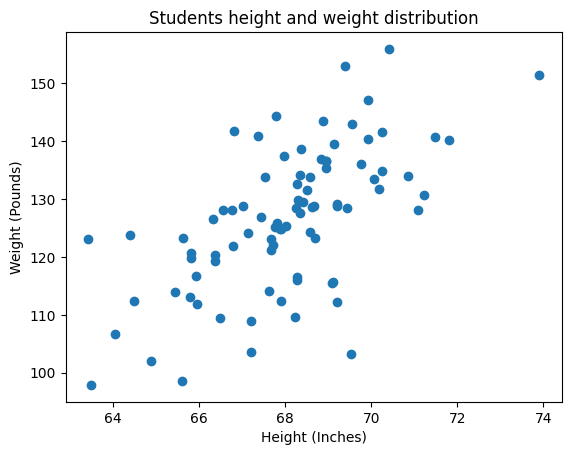

In [94]:
plt.scatter(df_female['Height (Inches)'], df_female['Weight (Pounds)'])
plt.xlabel('Height (Inches)') #x name
plt.ylabel('Weight (Pounds)') #y name
plt.title('Students height and weight distribution')
plt.show()

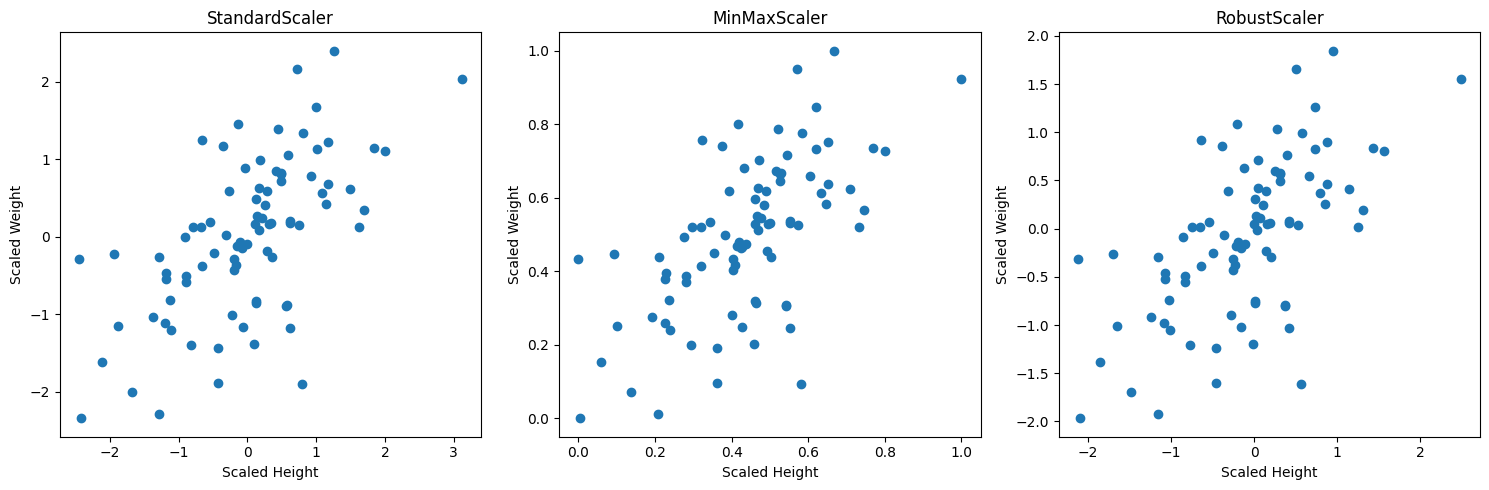

In [95]:
scalers = { #scaling methods
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5)) #make 3 subplots for each scaling method

for ax, (name, scaler) in zip(axes, scalers.items()): #apply each scaling method to height and weight columns and plot the results
    scaled = scaler.fit_transform(df_female[['Height (Inches)', 'Weight (Pounds)']])
    ax.scatter(scaled[:, 0], scaled[:, 1])
    ax.set_title(f'{name}')
    ax.set_xlabel('Scaled Height')
    ax.set_ylabel('Scaled Weight')

plt.tight_layout() # 서브 플롯들이 서로 겹치지 않게 자동으로 레이아웃을 조정
plt.show()

## Do the same for the groups diveded by BMI

### Group 1: BMI = 1

In [96]:
bmi1_df = df[df['BMI'] == 1]
bmi2_df = df[df['BMI'] == 2]
bmi3_df = df[df['BMI'] == 3]
datasets = {0: bmi1_df, 1: bmi2_df, 2: bmi3_df}

In [97]:
clean_datasets = []
for data, i in zip(datasets.values(), datasets.keys()):
    clean_datasets.append(data.fillna(0, inplace=True))
# drop row that has 0 or negative value in height and weight column
    clean_datasets[i] = clean_datasets[i][clean_datasets[i]['Height (Inches)'] > 0]
    clean_datasets[i] = clean_datasets[i][clean_datasets[i]['Weight (Pounds)'] > 0]
# drop row that has height value more than 100 and weight value more than 200
    clean_datasets[i] = clean_datasets[i][clean_datasets[i]['Height (Inches)'] < 100]
    clean_datasets[i] = clean_datasets[i][clean_datasets[i]['Weight (Pounds)'] < 200]

In [98]:
for i in range(3):
    print(clean_datasets[i])

       Sex  Age  Height (Inches)  Weight (Pounds)  BMI
30  Female   25          69.5233         103.3016  1.0
        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21         65.78331        112.99250  2.0
5    Female   22         68.69784        123.30240  2.0
8    Female   28         67.90265        112.37230  2.0
11   Female   28         67.62333        114.14300  2.0
14   Female   27         68.27967        116.08660  2.0
22   Female   31         63.48115         97.90191  2.0
28     Male   30         66.53401        108.33240  2.0
39   Female   23         64.04535        106.71150  2.0
44     Male   28         65.98088        106.44990  2.0
52     Male   29         70.26939        125.48390  2.0
53   Female   30         69.10344        115.70840  2.0
65   Female   26         68.21951        109.61130  2.0
68   Female   31         67.21568        103.52750  2.0
73     Male   22         64.28508        102.83510  2.0
78     Male   21         69.71947        115.62330

In [99]:
import numpy as np

In [100]:
for i in range(3):
# Train models on clean data
    reg_hw = LinearRegression().fit(clean_datasets[i][['Height (Inches)']], clean_datasets[i]['Weight (Pounds)'])
    reg_wh = LinearRegression().fit(clean_datasets[i][['Weight (Pounds)']], clean_datasets[i]['Height (Inches)'])

    r_sq_hw = reg_hw.score(clean_datasets[i][['Height (Inches)']], clean_datasets[i]['Weight (Pounds)'])
    r_sq_wh = reg_wh.score(clean_datasets[i][['Weight (Pounds)']], clean_datasets[i]['Height (Inches)'])
    print('coefficient of determination:', r_sq_hw)
    print('coefficient of determination:', r_sq_wh)
# List of indices with dirty data
    indices = np.array(datasets[i].index)

# Replace dirty values
    for idx in indices:
        # Check if height is dirty (negative, zero, or unreasonably high)
        if datasets[i].loc[idx, 'Height (Inches)'] <= 0 or datasets[i].loc[idx, 'Height (Inches)'] > 100:
        # Predict height using weight
            predicted_height = reg_wh.predict([[datasets[i].loc[idx, 'Weight (Pounds)']]])[0]
            datasets[i].loc[idx, 'Height (Inches)'] = predicted_height
    # Check if weight is dirty (negative or zero)
        if datasets[i].loc[idx, 'Weight (Pounds)'] <= 0 or datasets[i].loc[idx, 'Weight (Pounds)'] > 200:
        # Predict weight using height
            predicted_weight = reg_hw.predict([[datasets[i].loc[idx, 'Height (Inches)']]])[0]
            datasets[i].loc[idx, 'Weight (Pounds)'] = predicted_weight

print("Dirty data replaced with predicted values.")

coefficient of determination: nan
coefficient of determination: nan
coefficient of determination: 0.7392881082324259
coefficient of determination: 0.7392881082324262
coefficient of determination: 0.40920755834057165
coefficient of determination: 0.4092075583405709
Dirty data replaced with predicted values.


c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\UserName\AppData\Local\Programs\Python\Python314\Lib\si

In [101]:
for i in range(3):
    print(datasets[i])

       Sex  Age  Height (Inches)  Weight (Pounds)  BMI
30  Female   25          69.5233         103.3016  1.0
        Sex  Age  Height (Inches)  Weight (Pounds)  BMI
0    Female   21        65.783310       112.992500  2.0
5    Female   22        68.697840       123.302400  2.0
8    Female   28        67.902650       112.372300  2.0
11   Female   28        67.623330       114.143000  2.0
14   Female   27        68.279670       116.086600  2.0
22   Female   31        63.481150        97.901910  2.0
28     Male   30        66.534010       108.332400  2.0
39   Female   23        64.045350       106.711500  2.0
44     Male   28        65.980880       106.449900  2.0
47     Male   31        68.500054       116.819000  2.0
52     Male   29        70.269390       125.483900  2.0
53   Female   30        69.103440       115.708400  2.0
65   Female   26        68.219510       109.611300  2.0
68   Female   31        67.215680       103.527500  2.0
73     Male   22        64.285080       102.835100

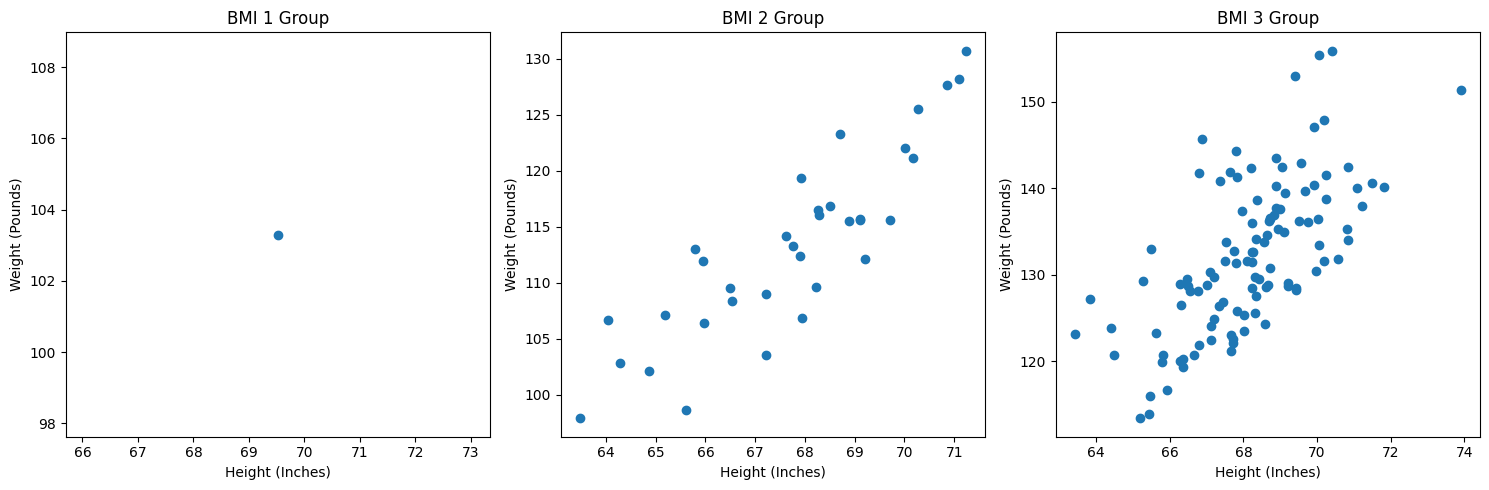

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5)) #make 3 subplots for each scaling method

for ax, i in zip(axes, datasets.keys()): #apply each scaling method to height and weight columns and plot the results
    ax.scatter(datasets[i][['Height (Inches)']], datasets[i][['Weight (Pounds)']])
    ax.set_title(f'BMI {i+1} Group')
    ax.set_xlabel('Height (Inches)')
    ax.set_ylabel('Weight (Pounds)')

plt.tight_layout() # 서브 플롯들이 서로 겹치지 않게 자동으로 레이아웃을 조정
plt.show()

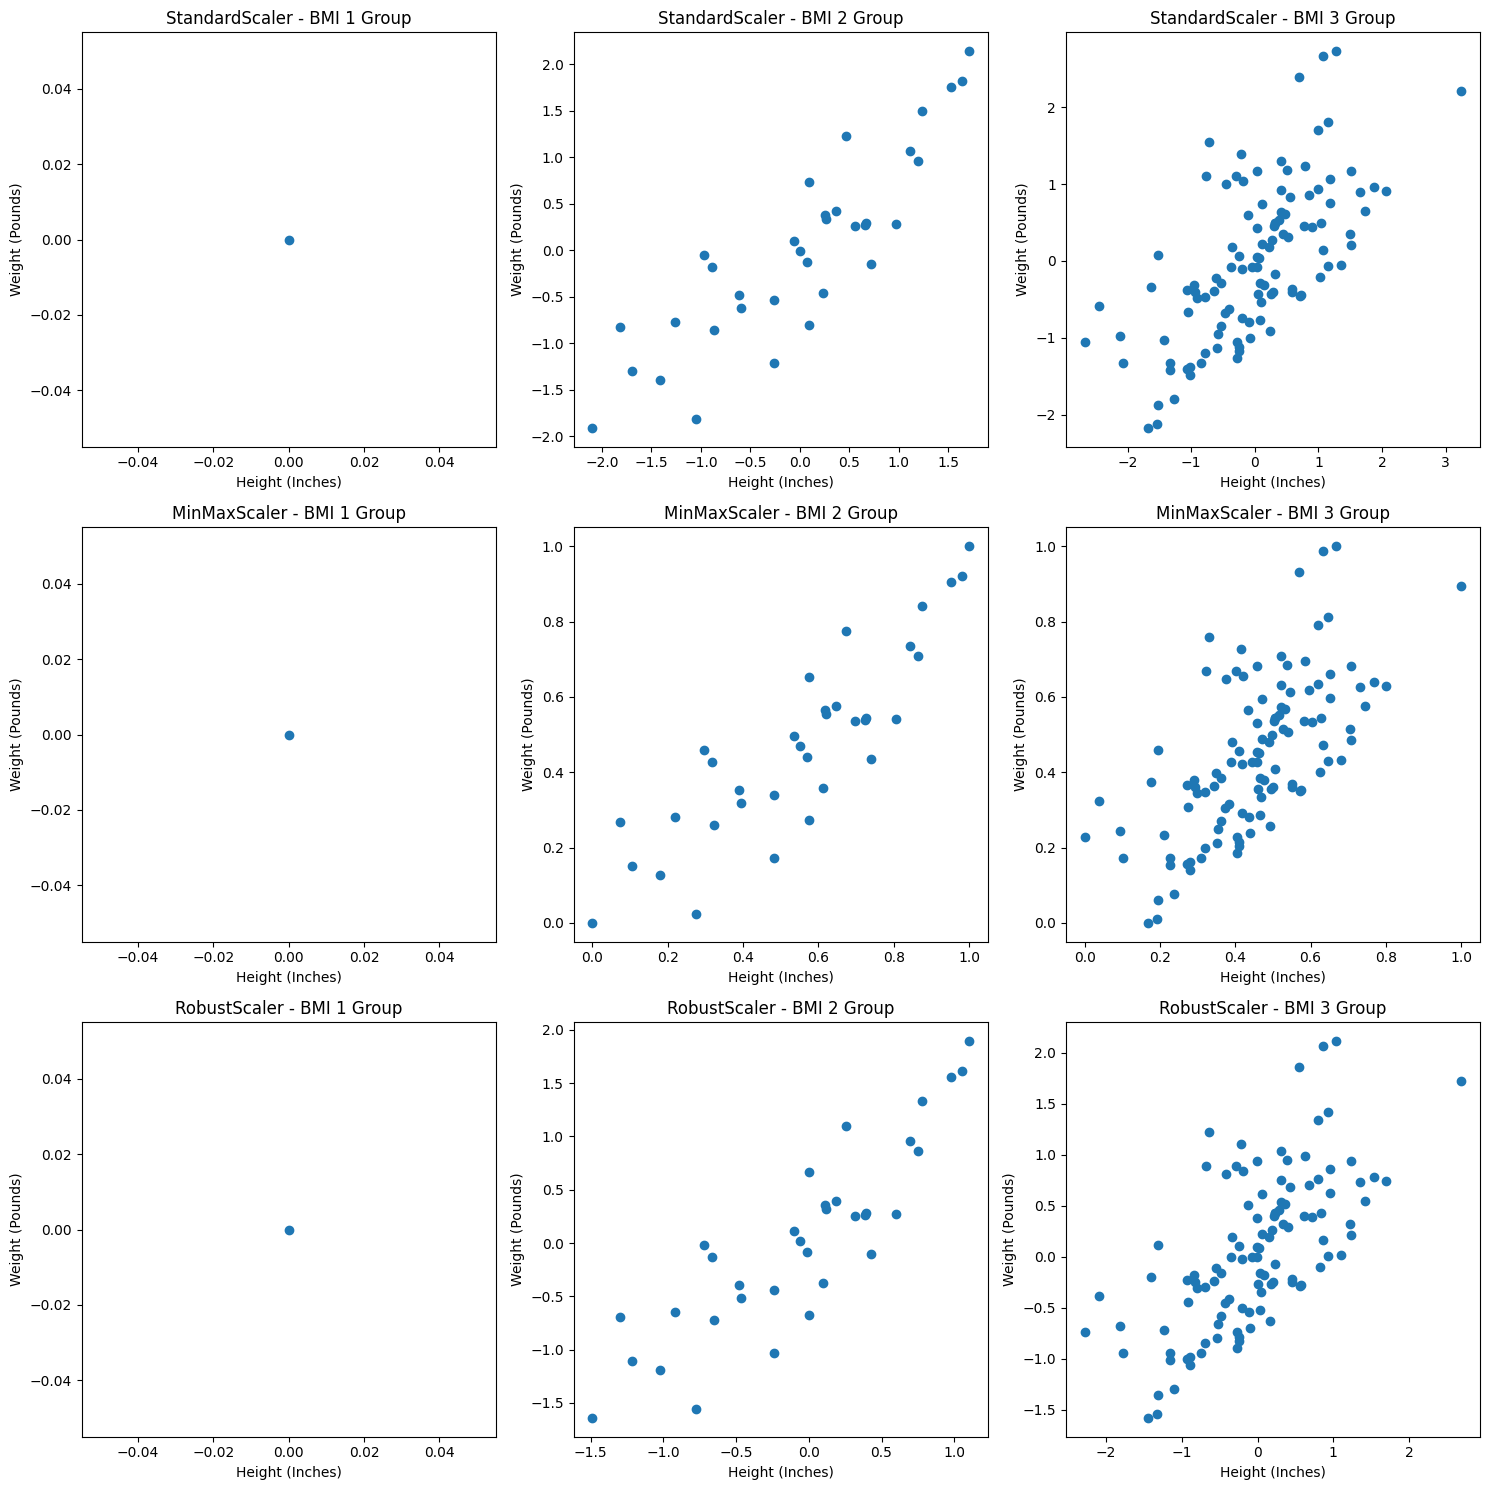

In [103]:
scalers = { #scaling methods
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

fig, axes = plt.subplots(3, 3, figsize=(15, 15)) #make 9 subplots for each scaling method

for i in range(3):
    for ax, (name, scaler) in zip(axes, scalers.items()): #apply each scaling method to height and weight columns and plot the results
        scaled = scaler.fit_transform(datasets[i][['Height (Inches)', 'Weight (Pounds)']])
        ax[i].scatter(scaled[:, 0], scaled[:, 1])
        ax[i].set_title(f'{name} - BMI {i+1} Group')
        ax[i].set_xlabel('Height (Inches)')
        ax[i].set_ylabel('Weight (Pounds)')

plt.tight_layout() # 서브 플롯들이 서로 겹치지 않게 자동으로 레이아웃을 조정
plt.show()